In [2]:
import numpy as np
import cv2
from imutils.object_detection import non_max_suppression
import pytesseract
from matplotlib import pyplot as plt
import spacy
import re
from langdetect import detect

In [3]:
#Creating argument dictionary for the default arguments needed in the code. 
args = {"image":"/home/volta/image_generation/img.jpg", "east":"/home/volta/OCR/frozen_east_text_detection.pb", "min_confidence":0.3, "width": 640, "height":640}

args['image']="/home/volta/image_generation/image_dataset/DATASET/custom_image_1_annotations/custom_image_1_1.png"
image = cv2.imread(args['image'])

#Saving a original image and shape
orig = image.copy()
(origH, origW) = image.shape[:2]

# set the new height and width to default 320 by using args #dictionary.  
(newW, newH) = (args["width"], args["height"])

#Calculate the ratio between original and new image for both height and weight. 
#This ratio will be used to translate bounding box location on the original image. 
rW = origW / float(newW)
rH = origH / float(newH)

# resize the original image to new dimensions
image = cv2.resize(image, (newW, newH))
(H, W) = image.shape[:2]

# construct a blob from the image to forward pass it to EAST model
blob = cv2.dnn.blobFromImage(image, 1.0, (W, H),
	(123.68, 116.78, 103.94), swapRB=True, crop=False)

net = cv2.dnn.readNet(args["east"])

# The following two layer need to pulled from EAST model for achieving this. 
layerNames = [
	"feature_fusion/Conv_7/Sigmoid",
	"feature_fusion/concat_3"]
  
#Forward pass the blob from the image to get the desired output layers
net.setInput(blob)
(scores, geometry) = net.forward(layerNames)




In [4]:
def predictions(prob_score, geo):
	(numR, numC) = prob_score.shape[2:4]
	boxes = []
	confidence_val = []

	# loop over rows
	for y in range(0, numR):
		scoresData = prob_score[0, 0, y]
		x0 = geo[0, 0, y]
		x1 = geo[0, 1, y]
		x2 = geo[0, 2, y]
		x3 = geo[0, 3, y]
		anglesData = geo[0, 4, y]

		# loop over the number of columns
		for i in range(0, numC):
			if scoresData[i] < args["min_confidence"]:
				continue

			(offX, offY) = (i * 4.0, y * 4.0)

			# extracting the rotation angle for the prediction and computing the sine and cosine
			angle = anglesData[i]
			cos = np.cos(angle)
			sin = np.sin(angle)

			# using the geo volume to get the dimensions of the bounding box
			h = x0[i] + x2[i]
			w = x1[i] + x3[i]

			# compute start and end for the text pred bbox
			endX = int(offX + (cos * x1[i]) + (sin * x2[i]))
			endY = int(offY - (sin * x1[i]) + (cos * x2[i]))
			startX = int(endX - w)
			startY = int(endY - h)

			boxes.append((startX, startY, endX, endY))
			confidence_val.append(scoresData[i])

	# return bounding boxes and associated confidence_val
	return (boxes, confidence_val)

(boxes, confidence_val) = predictions(scores, geometry)
boxes = non_max_suppression(np.array(boxes), probs=confidence_val)


In [5]:
boxes

array([[567,  61, 610,  79],
       [304, 138, 343, 151],
       [ 85, 198, 107, 209],
       [297, 387, 330, 399],
       [147, 284, 165, 295],
       [570,  82, 601,  97],
       [160, 284, 182, 295],
       [358, 334, 379, 345],
       [ 68, 365,  86, 379],
       [ 87, 364, 103, 380],
       [101, 365, 119, 380],
       [ 30, 374,  57, 397],
       [247, 389, 271, 401],
       [372, 152, 401, 164],
       [396,  70, 411,  84],
       [497, 287, 519, 300],
       [263, 386, 292, 400],
       [111, 549, 140, 561],
       [416, 463, 447, 473],
       [426, 206, 463, 217],
       [396,  93, 411, 110],
       [396, 118, 411, 132],
       [396, 170, 412, 183],
       [111, 253, 131, 266],
       [396, 271, 414, 284],
       [294, 435, 306, 517],
       [308, 424, 321, 536],
       [397, 219, 413, 233],
       [457, 617, 479, 630],
       [ 75,   2, 118,  15],
       [397, 243, 413, 258]])

In [5]:
##Text Detection and Recognition 

# initialize the list of results
results = []

# loop over the bounding boxes to find the coordinate of bounding boxes
for (startX, startY, endX, endY) in boxes:
	# scale the coordinates based on the respective ratios in order to reflect bounding box on the original image
	startX = int(startX * rW)
	startY = int(startY * rH)
	endX = int(endX * rW)
	endY = int(endY * rH)

	#extract the region of interest
	r = orig[startY:endY, startX:endX]

	#configuration setting to convert image to string.  
	configuration = ("-l eng --oem 1 --psm 8")
    ##This will recognize the text from the image of bounding box
	text = pytesseract.image_to_string(r, config=configuration)

	# append bbox coordinate and associated text to the list of results 
	results.append(((startX, startY, endX, endY), text))

In [6]:
results

[((1643, 90, 1768, 116), 'VOLTA.\n'),
 ((881, 203, 994, 222), '_ Jose Holloway\n'),
 ((246, 292, 310, 308), '00:06:46\n'),
 ((860, 571, 956, 589), '~ Byron Ward\n'),
 ((426, 419, 478, 435), '~ Abby»\n'),
 ((1652, 121, 1741, 143), '__AF-Xplorer_\n'),
 ((463, 419, 527, 435), 'y Green |\n'),
 ((1037, 493, 1098, 509), 'baeeDe\n'),
 ((197, 538, 249, 559), '941\n'),
 ((252, 537, 298, 561), '723\n'),
 ((292, 538, 344, 561), '0.32.\n'),
 ((86, 552, 165, 586), 'N/A\n'),
 ((715, 574, 785, 592), '_ Sabrina\n'),
 ((1078, 224, 1162, 242), '___Megan-M.\n'),
 ((1147, 103, 1191, 124), '0.00\n'),
 ((1440, 423, 1504, 442), 'R: 215ms"\n'),
 ((762, 569, 846, 590), 'ina Morales —\n'),
 ((321, 810, 405, 828), 'James P\n'),
 ((1205, 683, 1295, 698), '~ Connor Vale\n'),
 ((1234, 304, 1341, 320), 'lan Fletch@r— »\n'),
 ((1147, 137, 1191, 162), '0.00,\n'),
 ((1147, 174, 1191, 194), '0.00\n'),
 ((1147, 251, 1194, 270), '0.00\n'),
 ((321, 373, 379, 392), 'Cooper\n'),
 ((1147, 400, 1199, 419), '. 0.00 —\n'),
 ((85

In [50]:
results2 = []

nlp_en = spacy.load("en_core_web_sm")
nlp_fr = spacy.load("fr_core_news_sm")
nlp_ru = spacy.load("ru_core_news_sm")
nlp_es = spacy.load("es_core_news_sm")

# Function to detect language and perform NER
def detect_language_and_extract_names(text):
    text = re.sub(r'[^\w\s.,;\'"\-\—]', '', text) 
    try:
        # Detect language using langdetect
        language = detect(text)

        nlp = nlp_en
        if language in ("fr", "ru", "es"):
            nlp = {"fr": nlp_fr, "ru": nlp_ru, "es": nlp_es}[language]

        #nlp.add_pipe('merge_entities', after='ner')

        # Analyze the text with the chosen model
        doc = nlp(text)
        potential_names = [token.text for token in doc if token.is_title]

        # Filter person names (case-insensitive) using NER
        person_names = [ent.text for ent in doc.ents if ent.label_ == "PERSON"]
        all_names = set(potential_names) | set(person_names)
        return list(all_names)
    except Exception as e:
        print(f"Error in processing text: {text}")
        print(f"Error details: {str(e)}")
        return []

# Loop over the bounding boxes
for (startX, startY, endX, endY) in boxes:
    if boxes is None:
        continue
    startX = int(startX * rW)
    startY = int(startY * rH)
    endX = int(endX * rW)
    endY = int(endY * rH)

    # Extract the region of interest
    r = orig[startY:endY, startX:endX]

    configuration = ("-l eng --oem 1 --psm 8")
    
    text = pytesseract.image_to_string(r, config=configuration)

    # Skip processing if text contains only numeric values
    if text.strip().isdigit():
        continue

    person_names = detect_language_and_extract_names(text)

    # Append results only if person names are found
    if person_names:
        # Convert the list of person names to a single string
        person_names_str = ', '.join(person_names)
        
        # Append coordinates and person names as a tuple
        results2.append(((startX, startY, endX, endY), person_names_str))


Error in processing text: 000646

Error details: No features in text.
Error in processing text: 0.32.

Error details: No features in text.
Error in processing text: 0.00

Error details: No features in text.
Error in processing text: 0.00,

Error details: No features in text.
Error in processing text: 0.00

Error details: No features in text.
Error in processing text: 0.00

Error details: No features in text.
Error in processing text: . 0.00 —

Error details: No features in text.
Error in processing text: 

Error details: No features in text.
Error in processing text: 

Error details: No features in text.
Error in processing text: 0.00

Error details: No features in text.
Error in processing text: _ -23.03.23-1105..,

Error details: No features in text.
Error in processing text: 0.00

Error details: No features in text.


In [51]:
results2

[((881, 203, 994, 222), 'Jose, Jose Holloway, Holloway'),
 ((860, 571, 956, 589), 'Byron Ward, Ward, Byron'),
 ((426, 419, 478, 435), 'Abby'),
 ((463, 419, 527, 435), 'Green'),
 ((715, 574, 785, 592), 'Sabrina'),
 ((1078, 224, 1162, 242), 'Megan, Megan-M.\n, M.'),
 ((1440, 423, 1504, 442), 'R'),
 ((762, 569, 846, 590), 'Morales'),
 ((321, 810, 405, 828), 'P, James, James P\n'),
 ((1205, 683, 1295, 698), 'Vale, Connor, Connor Vale'),
 ((1234, 304, 1341, 320), 'Fletchr'),
 ((321, 373, 379, 392), 'Cooper')]

In [37]:
import csv


output_file = '/home/volta/OCR/output/NER.csv'

# Write the results to a CSV file
with open(output_file, 'w', newline='') as csvfile:
    fieldnames = ['StartX', 'StartY', 'EndX', 'EndY', 'PersonNames']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)

    # Write the header
    writer.writeheader()

    # Write the data
    for result in results2:
        writer.writerow({
            'StartX': result[0][0],
            'StartY': result[0][1],
            'EndX': result[0][2],
            'EndY': result[0][3],
            'PersonNames': result[1]
        })

print(f"Results saved to {output_file}")


Results saved to /home/volta/OCR/output/NER.csv


Jose, Jose Holloway, Holloway
Byron Ward, Ward, Byron
Abby
AF-Xplorer, Xplorer
Green
Sabrina
Megan, Megan-M.
, M.
R
Morales
P, James, James P

Vale, Connor, Connor Vale
Fletchr
Cooper


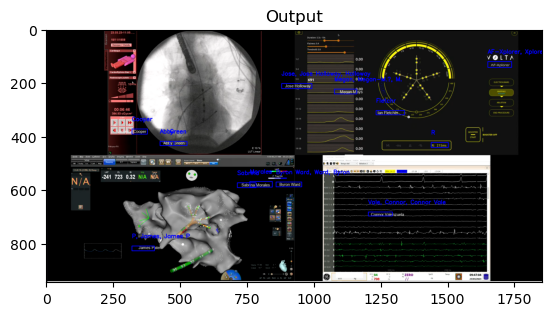

In [38]:
orig_image = orig.copy()

# Moving over the results and display on the image
for ((start_X, start_Y, end_X, end_Y), text) in results2:
	# display the text detected by Tesseract
	print("{}".format(text))

	# Displaying text
	text = "".join([x if ord(x) < 128 else "" for x in text]).strip()
	cv2.rectangle(orig_image, (start_X, start_Y), (end_X, end_Y),
		(0, 0, 255), 2)
	cv2.putText(orig_image, text, (start_X, start_Y - 30),
		cv2.FONT_HERSHEY_SIMPLEX, 0.7,(0,0, 255), 2)

plt.imshow(orig_image)
plt.title('Output')
plt.show()

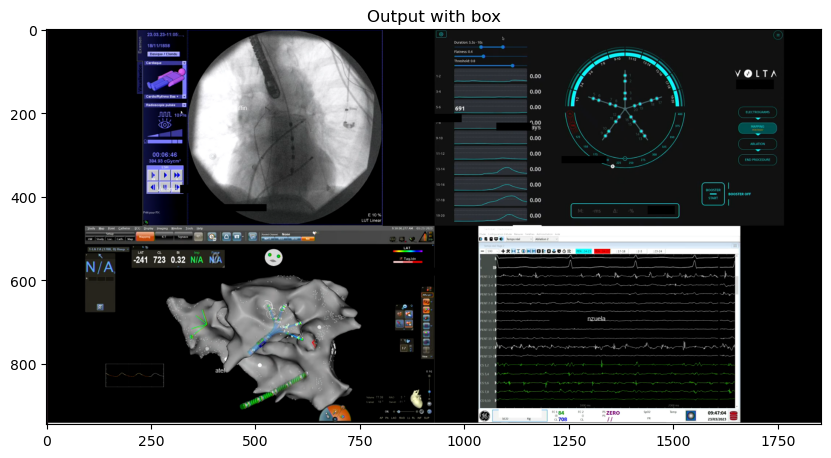

In [39]:
orig_img2= orig.copy()
for ((start_X, start_Y, end_X, end_Y), text) in results2:
    if not text:  # Skip non-detects
        continue
    # Draw only the bounding box on the image, without displaying the text
    cv2.rectangle(orig_img2, (start_X, start_Y), (end_X, end_Y), (0, 0, 0), -1)

# Display the image with the detected bounding boxes
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(orig_img2, cv2.COLOR_BGR2RGB))
plt.title('Output with box')
plt.show()



In [40]:
ground_truth = [(0, 0.4706199460916442, 0.6052910052910053, 0.042048517520215635, 0.01798941798941799),
(0 ,0.21347708894878706, 0.19047619047619047, 0.04582210242587601, 0.014814814814814815),
(0 ,0.3940700808625337, 0.6074074074074074, 0.05768194070080863, 0.014814814814814815),
(0 ,0.6549865229110512, 0.7238095238095238, 0.06684636118598383, 0.014814814814814815),
(0 ,0.5924528301886792, 0.23915343915343915, 0.04636118598382749, 0.01798941798941799),
(0 ,0.6684636118598383, 0.3216931216931217, 0.042048517520215635, 0.014814814814814815),
(0 ,0.2366576819407008, 0.44126984126984126, 0.042587601078167114, 0.01798941798941799),
(0 ,0.14285714285714285, 0.39576719576719577, 0.05983827493261455, 0.01798941798941799),
(0 ,0.48194070080862533, 0.21587301587301588, 0.05175202156334232, 0.01798941798941799),
(0 ,0.18652291105121294, 0.855026455026455, 0.044204851752021566, 0.014814814814814815)]

In [41]:
detected_boxes = [box for (box,text) in results2]
detected_boxes

[(881, 203, 994, 222),
 (860, 571, 956, 589),
 (426, 419, 478, 435),
 (1652, 121, 1741, 143),
 (463, 419, 527, 435),
 (715, 574, 785, 592),
 (1078, 224, 1162, 242),
 (1440, 423, 1504, 442),
 (762, 569, 846, 590),
 (321, 810, 405, 828),
 (1205, 683, 1295, 698),
 (1234, 304, 1341, 320),
 (321, 373, 379, 392)]

In [42]:
def yolo_to_east(yolo_box, image_width, image_height):
    x_center, y_center, width, height = yolo_box[1:]

    x1 = int((x_center - width / 2) * image_width)
    y1 = int((y_center - height / 2) * image_height)
    x2 = int((x_center + width / 2) * image_width)
    y2 = int((y_center + height / 2) * image_height)

    return x1, y1, x2, y2

ground_truth_yolo = [
    (0, 0.4706199460916442, 0.6052910052910053, 0.042048517520215635, 0.01798941798941799),
    (0, 0.4706199460916442, 0.6052910052910053, 0.042048517520215635, 0.01798941798941799),
(0 ,0.21347708894878706, 0.19047619047619047, 0.04582210242587601, 0.014814814814814815),
(0 ,0.3940700808625337, 0.6074074074074074, 0.05768194070080863, 0.014814814814814815),
(0 ,0.6549865229110512, 0.7238095238095238, 0.06684636118598383, 0.014814814814814815),
(0 ,0.5924528301886792, 0.23915343915343915, 0.04636118598382749, 0.01798941798941799),
(0 ,0.6684636118598383, 0.3216931216931217, 0.042048517520215635, 0.014814814814814815),
(0 ,0.2366576819407008, 0.44126984126984126, 0.042587601078167114, 0.01798941798941799),
(0 ,0.14285714285714285, 0.39576719576719577, 0.05983827493261455, 0.01798941798941799),
(0 ,0.48194070080862533, 0.21587301587301588, 0.05175202156334232, 0.01798941798941799),
(0 ,0.18652291105121294, 0.855026455026455, 0.044204851752021566, 0.014814814814814815)
]

image_width = 1855  # replace with your actual image width
image_height = 945  # replace with your actual image height

ground_truth_east = [yolo_to_east(box, image_width, image_height) for box in ground_truth_yolo]

print(ground_truth_east)


[(834, 563, 912, 580), (834, 563, 912, 580), (353, 172, 438, 187), (677, 567, 784, 581), (1153, 677, 1277, 691), (1056, 217, 1142, 234), (1201, 297, 1279, 311), (399, 408, 478, 425), (209, 365, 320, 382), (846, 195, 942, 212), (305, 801, 387, 815)]


In [46]:
def calculate_iou(box1, box2):
    x1, y1, x2, y2 = box1
    x3, y3, x4, y4 = box2

    intersection_area = max(0, min(x2, x4) - max(x1, x3)) * max(0, min(y2, y4) - max(y1, y3))
    box1_area = (x2 - x1) * (y2 - y1)
    box2_area = (x4 - x3) * (y4 - y3)
    union_area = box1_area + box2_area - intersection_area

    iou = intersection_area / union_area if union_area > 0 else 0
    return iou

def evaluate_performance(detected_boxes, ground_truth_boxes, iou_threshold=0.1):
    true_positives = 0
    false_positives = 0
    false_negatives = 0

    
    if not ground_truth_boxes:
        return 0, 0, 0

    for detected_box in detected_boxes:
        max_iou = 0
        for ground_truth_box in ground_truth_boxes:
            iou = calculate_iou(detected_box, ground_truth_box)
            max_iou = max(max_iou, iou)

        
        if max_iou >= iou_threshold:
            true_positives += 1
        else:
            false_positives += 1

    
    false_negatives = len(ground_truth_boxes) - true_positives

    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return precision, recall, f1_score


precision, recall, f1_score = evaluate_performance(detected_boxes, ground_truth_east)
print(f"Precision: {precision:.2f}, Recall: {recall:.2f}, F1 Score: {f1_score:.2f}")


Precision: 0.62, Recall: 0.73, F1 Score: 0.67


1855 945


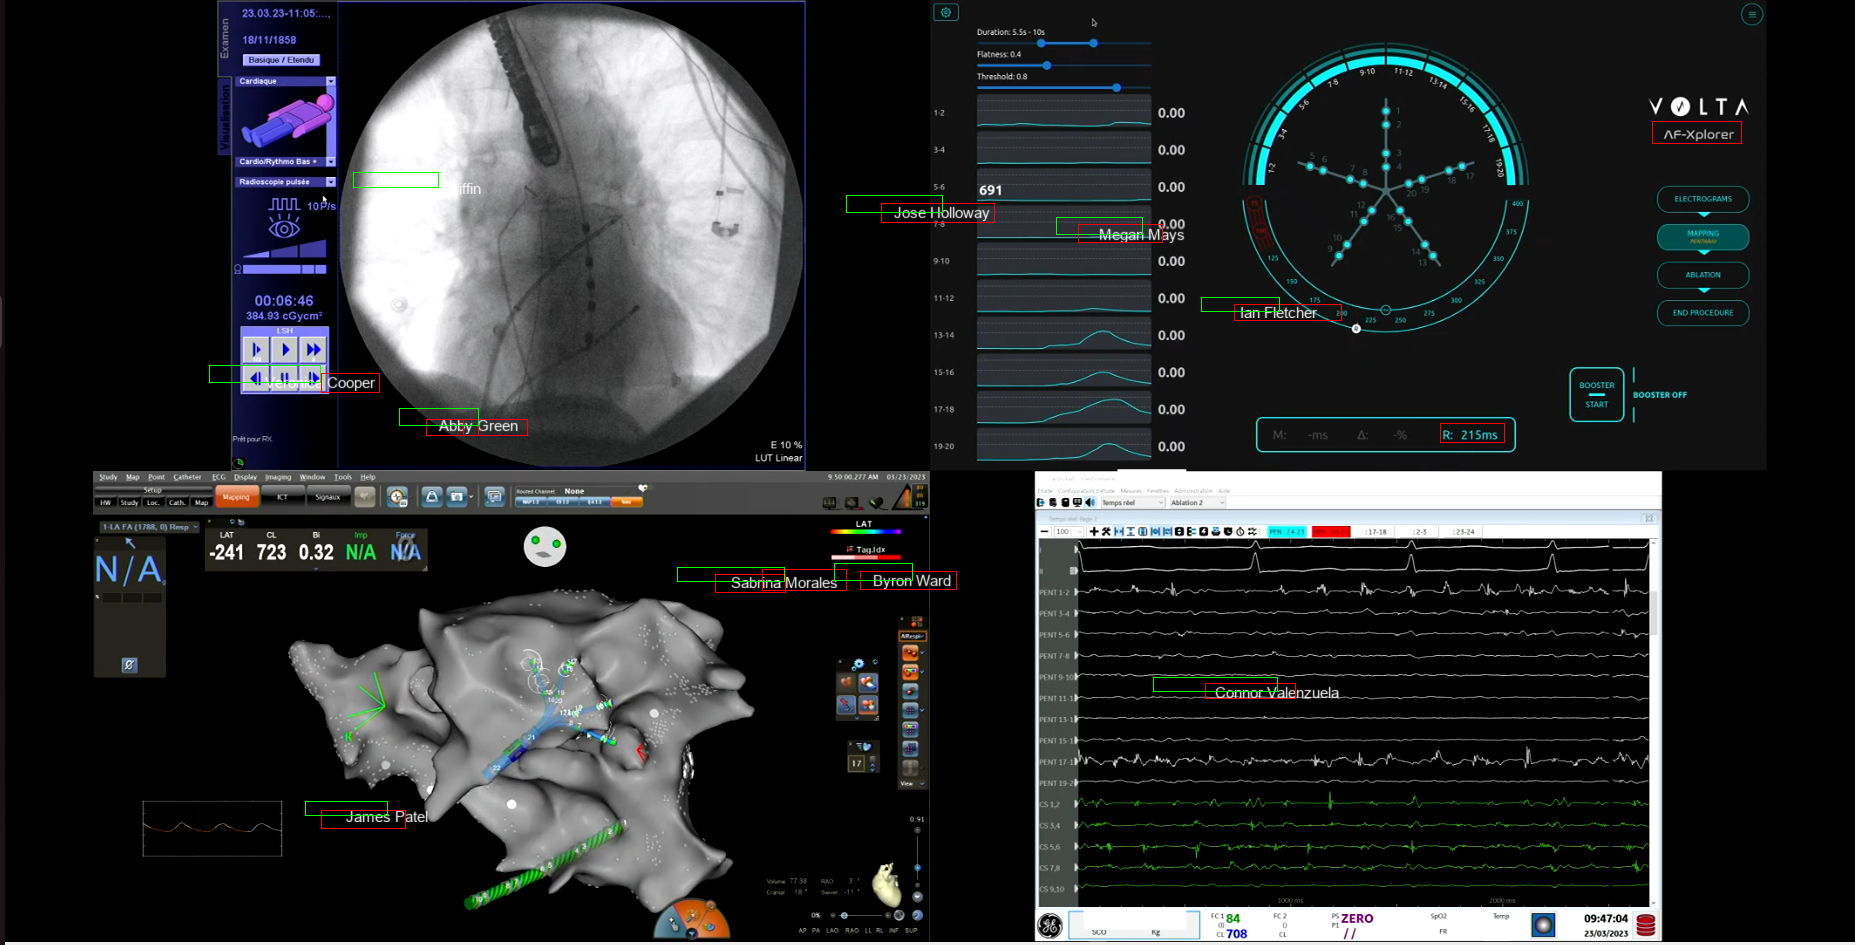

In [45]:
from PIL import Image, ImageDraw

imgp = Image.open(args['image'])
imgd = ImageDraw.Draw(imgp)

print(imgp.width, imgp.height)

for box in detected_boxes :
    imgd.rectangle(box, outline=(255,0,0))

for box in ground_truth_east :
    imgd.rectangle(box, outline=(0,255,0))

# imgp.save('/home/volta/boxes.png')
imgp

In [53]:
bd = {0: [1,2,3,4], 1: [10,20,30,40], 2: [100,200,300, 400], 3: [1000,2000,3000,4000]}
bdl = []
for i in range(len(bd)):
    bdl.append(bd[i])
    print(bdl[i])
#print(bdl)

[1, 2, 3, 4]
[10, 20, 30, 40]
[100, 200, 300, 400]
[1000, 2000, 3000, 4000]
